# Peak Demand Timing Analytics and Logistic Regression Model

This notebook helps analyze peak booking demand and build a simple logistic regression model to predict whether an order belongs to a peak-demand period.

## Problem Statement
The business currently lacks visibility into peak booking periods, which may lead to inefficient rider allocation and limited pickup capacity during high-demand windows. This notebook uses time-based analytics to identify peak booking periods and a logistic regression model to predict peak-demand orders.

## Business Objective
- Identify the busiest booking hours
- Understand demand patterns by day of week
- Predict whether an order falls into a peak-demand period
- Support decisions such as increasing pickup slots and allocating more riders during peak periods


## Recommended Features

Used in the model:
- `booking_hour`
- `booking_day_of_week`
- `zone`
- `category`
- `quantity`

Not used in the first model:
- `order_id` (identifier only)
- `order_value_sgd` (better for separate value analysis)
- `processing_days`, `processing_label`, `order_status` (operational outcomes / leakage)
- `delivery_slot` (more useful for downstream fulfillment analysis)


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


## 2. Load Data

In [3]:
df = pd.read_csv('../../data1/astoria_orders.csv')
df.head()

,order_id,booking_date,booking_time,booking_hour,booking_day_of_week,collection_date,collection_time,delivery_date,delivery_slot,zone,...,base_price_sgd,delicate_surcharge,express_type,express_multiplier,order_value_sgd,free_delivery,processing_days,processing_label,effort_score,order_status
0,AST-00001,2024-06-07,11:15,11,Friday,2024-06-07,14:46,2024-06-10,15:00-18:00,Choa Chu Kang / Bukit Panjang,...,9,0,NaN,1.0,8.83,No,2,1-2 days,1,Completed
1,AST-00002,2024-03-23,11:24,11,Saturday,2024-03-23,16:07,2024-03-25,15:00-18:00,Buona Vista / Holland,...,18,0,NaN,1.0,35.73,No,2,1-2 days,2,Completed
2,AST-00003,2024-04-19,10:08,10,Friday,2024-04-19,15:55,2024-04-22,12:00-16:00,Choa Chu Kang / Bukit Panjang,...,20,0,Next-day,2.0,117.66,Yes,3,3-6 days,2,Completed
3,AST-00004,2024-08-30,21:25,21,Friday,2024-08-31,11:31,2024-09-04,15:00-18:00,Punggol / Sengkang,...,55,0,NaN,1.0,53.35,Yes,4,3-6 days,3,Completed
4,AST-00005,2024-11-01,10:33,10,Friday,2024-11-01,12:13,2024-11-04,09:00-13:00,Tampines / Pasir Ris,...,30,0,NaN,1.0,29.73,No,3,3-6 days,2,Completed


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             5000 non-null   object 
 1   booking_date         5000 non-null   object 
 2   booking_time         5000 non-null   object 
 3   booking_hour         5000 non-null   int64  
 4   booking_day_of_week  5000 non-null   object 
 5   collection_date      5000 non-null   object 
 6   collection_time      5000 non-null   object 
 7   delivery_date        5000 non-null   object 
 8   delivery_slot        5000 non-null   object 
 9   zone                 5000 non-null   object 
 10  postal_district      5000 non-null   object 
 11  postal_code          5000 non-null   int64  
 12  latitude             5000 non-null   float64
 13  longitude            5000 non-null   float64
 14  service              5000 non-null   object 
 15  category             5000 non-null   o

## 3. Data Cleansing

Date fields are converted into datetime format, and relevant columns are standardised into numeric types.

Invalid or inconsistent values are coerced into missing values (NaN), ensuring that data quality issues are properly identified and handled before modelling.

In [5]:
# Convert date columns if present
date_cols = ['booking_date', 'collection_date', 'delivery_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# Convert likely numeric columns
numeric_cols = [
    'booking_hour', 'quantity', 'base_price_sgd', 'delicate_surcharge',
    'express_multiplier', 'order_value_sgd', 'processing_days',
    'effort_score', 'latitude', 'longitude'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)


order_id                       object
booking_date           datetime64[ns]
booking_time                   object
booking_hour                    int64
booking_day_of_week            object
collection_date        datetime64[ns]
collection_time                object
delivery_date          datetime64[ns]
delivery_slot                  object
zone                           object
postal_district                object
postal_code                     int64
latitude                      float64
longitude                     float64
service                        object
category                       object
quantity                        int64
base_price_sgd                  int64
delicate_surcharge              int64
express_type                   object
express_multiplier            float64
order_value_sgd               float64
free_delivery                  object
processing_days                 int64
processing_label               object
effort_score                    int64
order_status

## 4. Define target variable

Peak-demand hours are defined as those with order volumes above the 75th percentile of hourly demand.

In [6]:
# Create hourly demand table
hourly = df.groupby('booking_hour').size().reset_index(name='order_count')
threshold = hourly['order_count'].quantile(0.75)

peak_hours = hourly.loc[
    hourly['order_count'] >= threshold, 
    'booking_hour'
].tolist()

df['is_peak'] = df['booking_hour'].isin(peak_hours).astype(int)

print('Peak threshold:', threshold)
print('Peak hours identified:', peak_hours)

print('\nClass distribution:')
print(df['is_peak'].value_counts())

print('\nClass proportion:')
print(df['is_peak'].value_counts(normalize=True))


Peak threshold: 308.0
Peak hours identified: [8, 9, 10, 18, 20, 21, 22]

Class distribution:
is_peak
1    2862
0    2138
Name: count, dtype: int64

Class proportion:
is_peak
1    0.5724
0    0.4276
Name: proportion, dtype: float64


Peak demand is concentrated during early morning (8–10 AM) and evening hours (6 PM, 8–10 PM), indicating that customers tend to place orders before and after typical working hours.

## 5. Exploratory Data Analysis
### Analytics: Peak Demand by Booking Hour

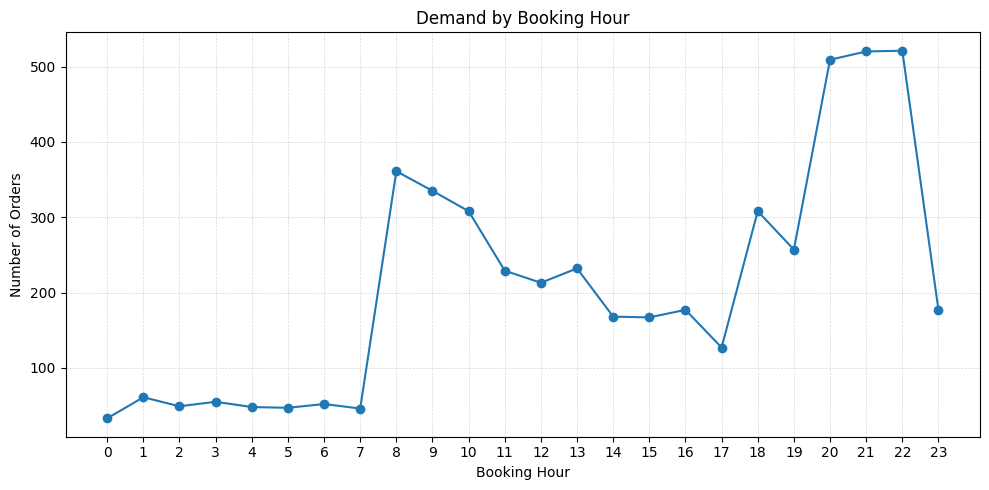

In [7]:
plt.figure(figsize=(10,5))

plt.plot(hourly['booking_hour'], hourly['order_count'], marker='o')

plt.title('Demand by Booking Hour')
plt.xlabel('Booking Hour')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))

# ✨ Improved grid
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()


Demand is low during early hours (midnight–7 AM), increases from 8 AM, and peaks during 8–10 AM and 8–10 PM, with a dip in mid-day.

- Peak demand occurs **before and after working hours**, reflecting customer booking behaviour and convenience  
- Indicates when customers are most likely to submit orders on the platform  
- Suggests higher system and support responsiveness during **8–10 AM and 8–10 PM**  

These insights support better demand planning and improved customer experience.

### Analytics: Demand by Day of Week

,booking_day_of_week,order_count
1,Monday,823
4,Tuesday,815
5,Wednesday,820
3,Thursday,823
0,Friday,875
2,Saturday,844


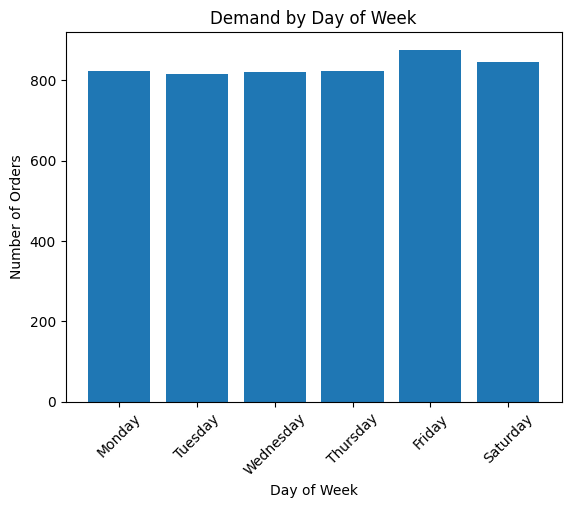

In [8]:
dow = df.groupby('booking_day_of_week')['order_id'].count().reset_index()
dow.columns = ['booking_day_of_week', 'order_count']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow['booking_day_of_week'] = pd.Categorical(dow['booking_day_of_week'], categories=day_order, ordered=True)
dow = dow.sort_values('booking_day_of_week')

display(dow)

plt.bar(dow['booking_day_of_week'], dow['order_count'])
plt.title('Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()


Demand is relatively consistent throughout the week, with a slight increase on Fridays. This suggests that demand is not heavily dependent on specific weekdays, but rather driven by time-of-day behaviour.

## 6. Feature Engineering

Key features related to booking behaviour, location, and order characteristics are selected to capture patterns influencing peak demand.

Missing values are handled to ensure data quality, and categorical variables are encoded into numerical form using one-hot encoding for model compatibility.

This enables the model to better learn demand patterns and improve prediction accuracy.

In [9]:
selected_features = ['booking_hour', 'booking_day_of_week', 'zone', 'category', 'quantity']
selected_features = [col for col in selected_features if col in df.columns]

X = df[selected_features].copy()
y = df['is_peak'].copy()

print("Selected features:", selected_features)
X.head()

# Fill missing values
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna('Unknown')

for col in X.select_dtypes(include=['number']).columns:
    X[col] = X[col].fillna(X[col].median())

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)
print("Encoded feature shape:", X_encoded.shape)
X_encoded.head()


Selected features: ['booking_hour', 'booking_day_of_week', 'zone', 'category', 'quantity']
Encoded feature shape: (5000, 33)


,booking_hour,quantity,booking_day_of_week_Monday,booking_day_of_week_Saturday,booking_day_of_week_Thursday,booking_day_of_week_Tuesday,booking_day_of_week_Wednesday,zone_Bedok / Chai Chee,zone_Bishan / Toa Payoh,zone_Boon Lay / Tuas,...,zone_Tampines / Pasir Ris,zone_Woodlands / Marsiling,zone_Yishun / Sembawang,category_Alterations,category_Bags & Shoes,category_Clothing,category_Household,category_On-site,category_Special,category_Traditional
0,11,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,11,2,False,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,10,3,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,21,1,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,10,1,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False


## 7. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (4000, 33)
X_test shape: (1000, 33)
y_train distribution:
 is_peak
1    0.5725
0    0.4275
Name: proportion, dtype: float64
y_test distribution:
 is_peak
1    0.572
0    0.428
Name: proportion, dtype: float64


## 8. Train Model

In [11]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## 9. Model Evaluation

In [12]:
y_pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred,target_names=['Non-Peak', 'Peak']))


Accuracy: 0.633

Classification Report:
              precision    recall  f1-score   support

    Non-Peak       0.57      0.61      0.59       428
        Peak       0.69      0.65      0.67       572

    accuracy                           0.63      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.64      0.63      0.63      1000



Model Performance: 
The logistic regression model achieved an accuracy of 63.3%, indicating a moderate ability to predict peak demand orders. This is acceptable given the variability in customer booking behaviour.

Classification Performance 
The model shows relatively balanced performance:
- Recall is 65% for peak orders and 61% for non-peak orders, indicating it can reasonably distinguish between high- and low-demand periods  
- Precision is higher for peak orders (69%), meaning predicted peaks are generally reliable  

The F1-score (0.67 for peak, 0.59 for non-peak) reflects a balanced trade-off between precision and recall, showing the model performs better in identifying peak demand.

Data Distribution: 
The dataset contains slightly more peak cases (572) than non-peak cases (428), which may influence model performance.

Overall, the model provides useful demand insights that can support planning decisions. It is more effective at identifying peak periods, which is critical for ensuring service readiness during high-demand periods.

## 10. Confusion Matrix

The confusion matrix provides a detailed breakdown of prediction outcomes for peak demand periods:

- **True Positive (TP)**: model correctly predicts a peak period — sufficient manpower can be allocated in advance  
- **True Negative (TN)**: model correctly predicts a non-peak period — resources are not over-allocated  
- **False Positive (FP)**: model predicts peak demand but it is actually non-peak — leads to slight overstaffing  
- **False Negative (FN)**: model fails to detect a peak period — results in understaffing during high demand  

From an operational standpoint, false negatives are more critical than false positives. Missing a peak demand period may lead to delayed collections, longer processing times, and reduced customer satisfaction. 

In contrast, a false positive only results in minor inefficiencies, such as slightly higher manpower allocation, which has a lower impact on service quality.

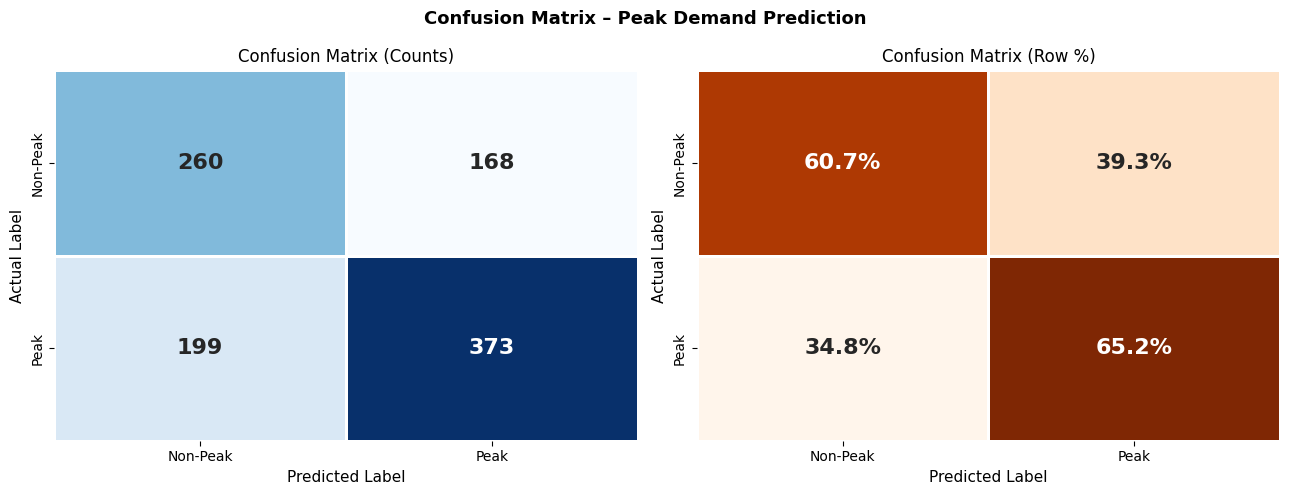

True Negatives  (TN):  260  - non-peak periods correctly identified
False Positives (FP):  168  - predicted peak but actually non-peak (possible overstaffing)
False Negatives (FN):  199  - missed peak periods (risk of understaffing)
True Positives  (TP):  373  - peak periods correctly identified

Operationally, 199 out of 572 peak periods were missed (34.8%).


In [13]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# 1. Raw Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Peak', 'Peak'],
            yticklabels=['Non-Peak', 'Peak'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'}, cbar=False)

axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_title('Confusion Matrix (Counts)')

# 2. Normalised (Row %)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Oranges', ax=axes[1],
            xticklabels=['Non-Peak', 'Peak'],
            yticklabels=['Non-Peak', 'Peak'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'}, cbar=False)

axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_title('Confusion Matrix (Row %)')

plt.suptitle('Confusion Matrix – Peak Demand Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Business Interpretation
print(f'True Negatives  (TN): {tn:>4}  - non-peak periods correctly identified')
print(f'False Positives (FP): {fp:>4}  - predicted peak but actually non-peak (possible overstaffing)')
print(f'False Negatives (FN): {fn:>4}  - missed peak periods (risk of understaffing)')
print(f'True Positives  (TP): {tp:>4}  - peak periods correctly identified')

print()

# Avoid division error
if (tp + fn) > 0:
    miss_rate = fn / (tp + fn) * 100
    print(f'Operationally, {fn} out of {tp+fn} peak periods were missed ({miss_rate:.1f}%).')
else:
    print("No peak cases in test set.")

### Key Insights

- The model correctly identifies most peak periods (~65%), supporting more effective demand planning.  
- However, ~35% of peak periods are missed, which may lead to understaffing and service delays.  
- Around 40% of non-peak periods are incorrectly flagged as peak, resulting in minor overstaffing.  

### Business Implication

- Missing peak demand is more critical than overstaffing, as it directly impacts service quality.  
- The model is useful for planning, but should be further tuned to improve peak detection (recall).  

Therefore, priority should be placed on reducing missed peaks to ensure reliable service during high-demand periods.

## 11. Feature Importance
Positive coefficients suggest higher likelihood of peak demand.

In [14]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_[0]
})

feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)
feature_importance


,Feature,Coefficient
30,category_On-site,0.350950
9,zone_Boon Lay / Tuas,0.297034
32,category_Traditional,0.242012
21,zone_Queenstown / Alexandra,0.220921
28,category_Clothing,0.202327
23,zone_Tampines / Pasir Ris,0.184355
18,zone_Novena / Newton,0.179235
7,zone_Bedok / Chai Chee,0.168144
16,zone_Jurong East / West,0.155818
8,zone_Bishan / Toa Payoh,0.127938


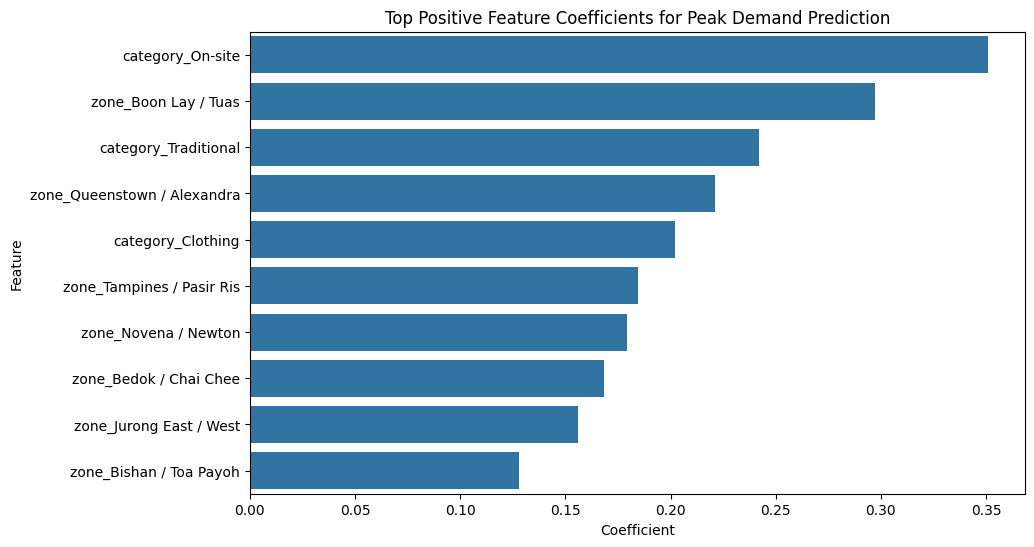

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x='Coefficient',
    y='Feature'
)
plt.title("Top Positive Feature Coefficients for Peak Demand Prediction")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

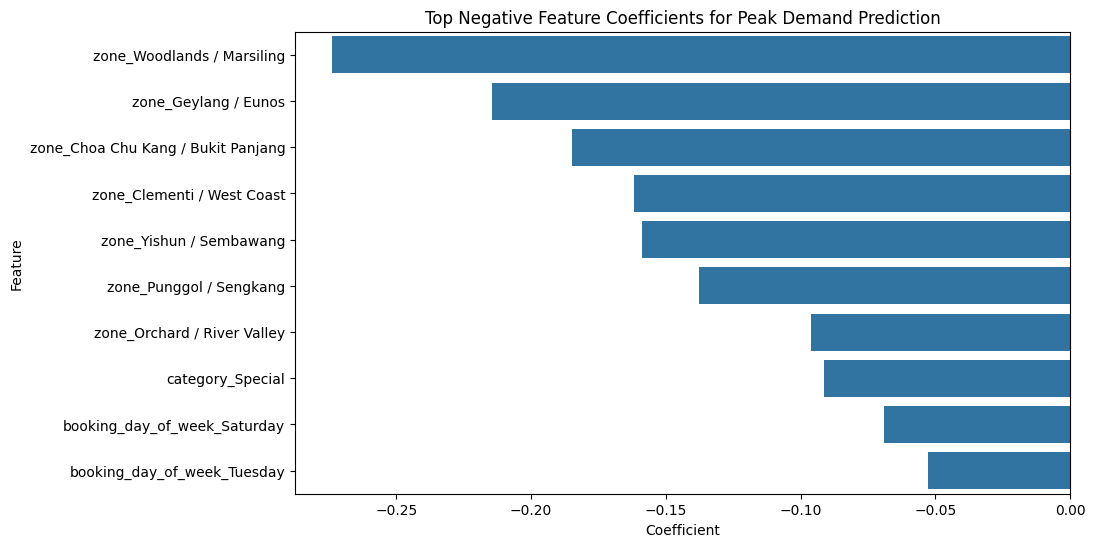

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.sort_values(by='Coefficient', ascending=True).head(10),
    x='Coefficient',
    y='Feature'
)
plt.title("Top Negative Feature Coefficients for Peak Demand Prediction")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Feature Insights

**1. Positive drivers (increase likelihood of peak demand):**
- Service categories such as On-site, Traditional, and Clothing are more likely to occur during peak periods, indicating higher demand for these services during busy time windows  
- Certain locations (e.g. Boon Lay / Tuas, Queenstown, Tampines) show stronger peak demand patterns  
- Booking hour remains a key driver, reinforcing the importance of time-based customer behaviour  

**2. Negative drivers (lower likelihood of peak demand):**
- Zones such as Woodlands / Marsiling, Geylang / Eunos, and Choa Chu Kang are less likely to experience peak demand, suggesting more off-peak activity in these areas  
- Certain time patterns (e.g. specific weekdays like Tuesday and Saturday) are also associated with lower peak demand  

Overall, demand varies by service type, location, and timing, enabling more targeted and data-driven planning.

## 12. Summary 

### Key Insights

- Demand peaks during early morning (8–10 AM) and evening hours (6–10 PM), reflecting pre-work and post-work customer booking behaviour  
- Demand is relatively consistent across weekdays, with a slight increase on Fridays, indicating stable demand patterns  
- Booking hour is identified as a key driver of peak demand, highlighting the importance of time-based behaviour  
- Service category and geographic zone also influence demand, suggesting that both service type and location affect peak patterns  

### Business Recommendations

- Ensure higher system responsiveness and booking capacity during peak periods (8–10 AM and 6–10 PM)  
- Use peak demand insights to support manpower and operational planning downstream  
- Focus resources on high-demand zones (e.g. Queenstown, Tampines)  
- Maintain baseline capacity during non-peak periods to optimise resource utilisation  

### Business Impact

- Improved responsiveness during peak booking periods  
- Better anticipation of demand inflow for operational planning  
- More efficient resource allocation across time and location  
- Enhanced overall customer experience and service reliability  